<a href="https://colab.research.google.com/github/HyaGo01/smart_city/blob/main/SmartCity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Grupo 3: Smart City
Alunos: Hyago Rhenan, Ítalo Huan,  Fernando Cobianchi

**Cenário:** câmeras de segurança noturnas tentam capturar placas de veículos em fuga. As imagens costumam sofrer com baixa iluminação, baixo contraste, ruído de sensor/compressão e borrão de movimento.

**Foco da pesquisa:** comparação entre **Equalização de Histograma global vs. CLAHE** e **Canny vs. Sobel** em condições sub-ótimas.

**Entregas deste notebook:**
1. Diagnóstico do problema/degradação da imagem.
2. Pipeline sugerido e executável.
3. Justificativa técnica das escolhas.
4. Código pronto para Google Colab.


Passo 1: Carregar a imagem

Entrada: imagem noturna de veículo em movimento.

In [21]:
!wget https://raw.githubusercontent.com/HyaGo01/smart_city/main/carro01.jpeg

--2026-04-28 00:59:27--  https://raw.githubusercontent.com/HyaGo01/smart_city/main/carro01.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 58541 (57K) [image/jpeg]
Saving to: ‘carro01.jpeg.1’

carro01.jpeg.1      100%[===================>]  57.17K  --.-KB/s    in 0.01s   

2026-04-28 00:59:27 (4.89 MB/s) - ‘carro01.jpeg.1’ saved [58541/58541]



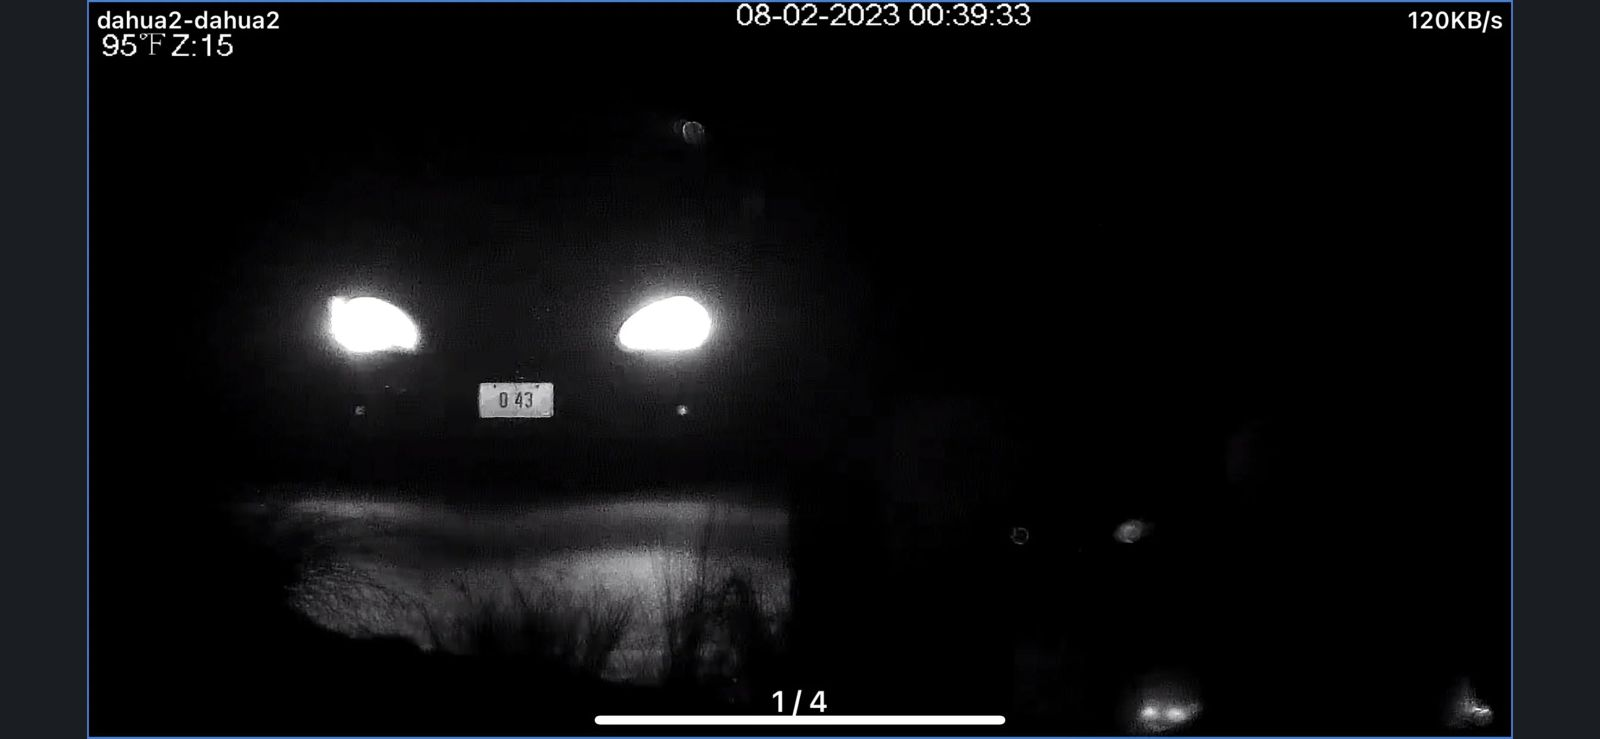

In [22]:
from IPython.display import Image

Image(filename='carro01.jpeg')

Passo 2: Selecionar a região de interesse

Sempre que possível, recortar a região onde está o veículo ou a placa. Isso reduz interferência do fundo, faróis, postes e outros objetos.

roi = img[y1:y2, x1:x2]

Justificativa: a placa ocupa uma pequena parte da imagem. Trabalhar na imagem inteira pode fazer o algoritmo detectar bordas irrelevantes, como faróis, rodas, postes e sombras.

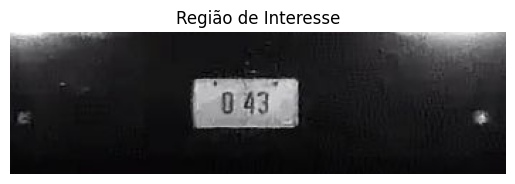

In [23]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('carro01.jpeg')

y1, y2 = 350, 450
x1, x2 = 350, 700

img_height, img_width = img.shape[:2]
y1 = max(0, y1)
y2 = min(img_height, y2)
x1 = max(0, x1)
x2 = min(img_width, x2)

if y2 > y1 and x2 > x1:
    roi = img[y1:y2, x1:x2]
else:
    print("Invalid ROI coordinates, displaying full image.")
    roi = img.copy() # Fallback to full image if ROI is invalid

plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title('Região de Interesse')
plt.axis('off')
plt.show()

Passo 2: Selecionar a região de interesse

Sempre que possível, recortar a região onde está o veículo ou a placa. Isso reduz interferência do fundo, faróis, postes e outros objetos.

Justificativa: a placa ocupa uma pequena parte da imagem. Trabalhar na imagem inteira pode fazer o algoritmo detectar bordas irrelevantes, como faróis, rodas, postes e sombras.

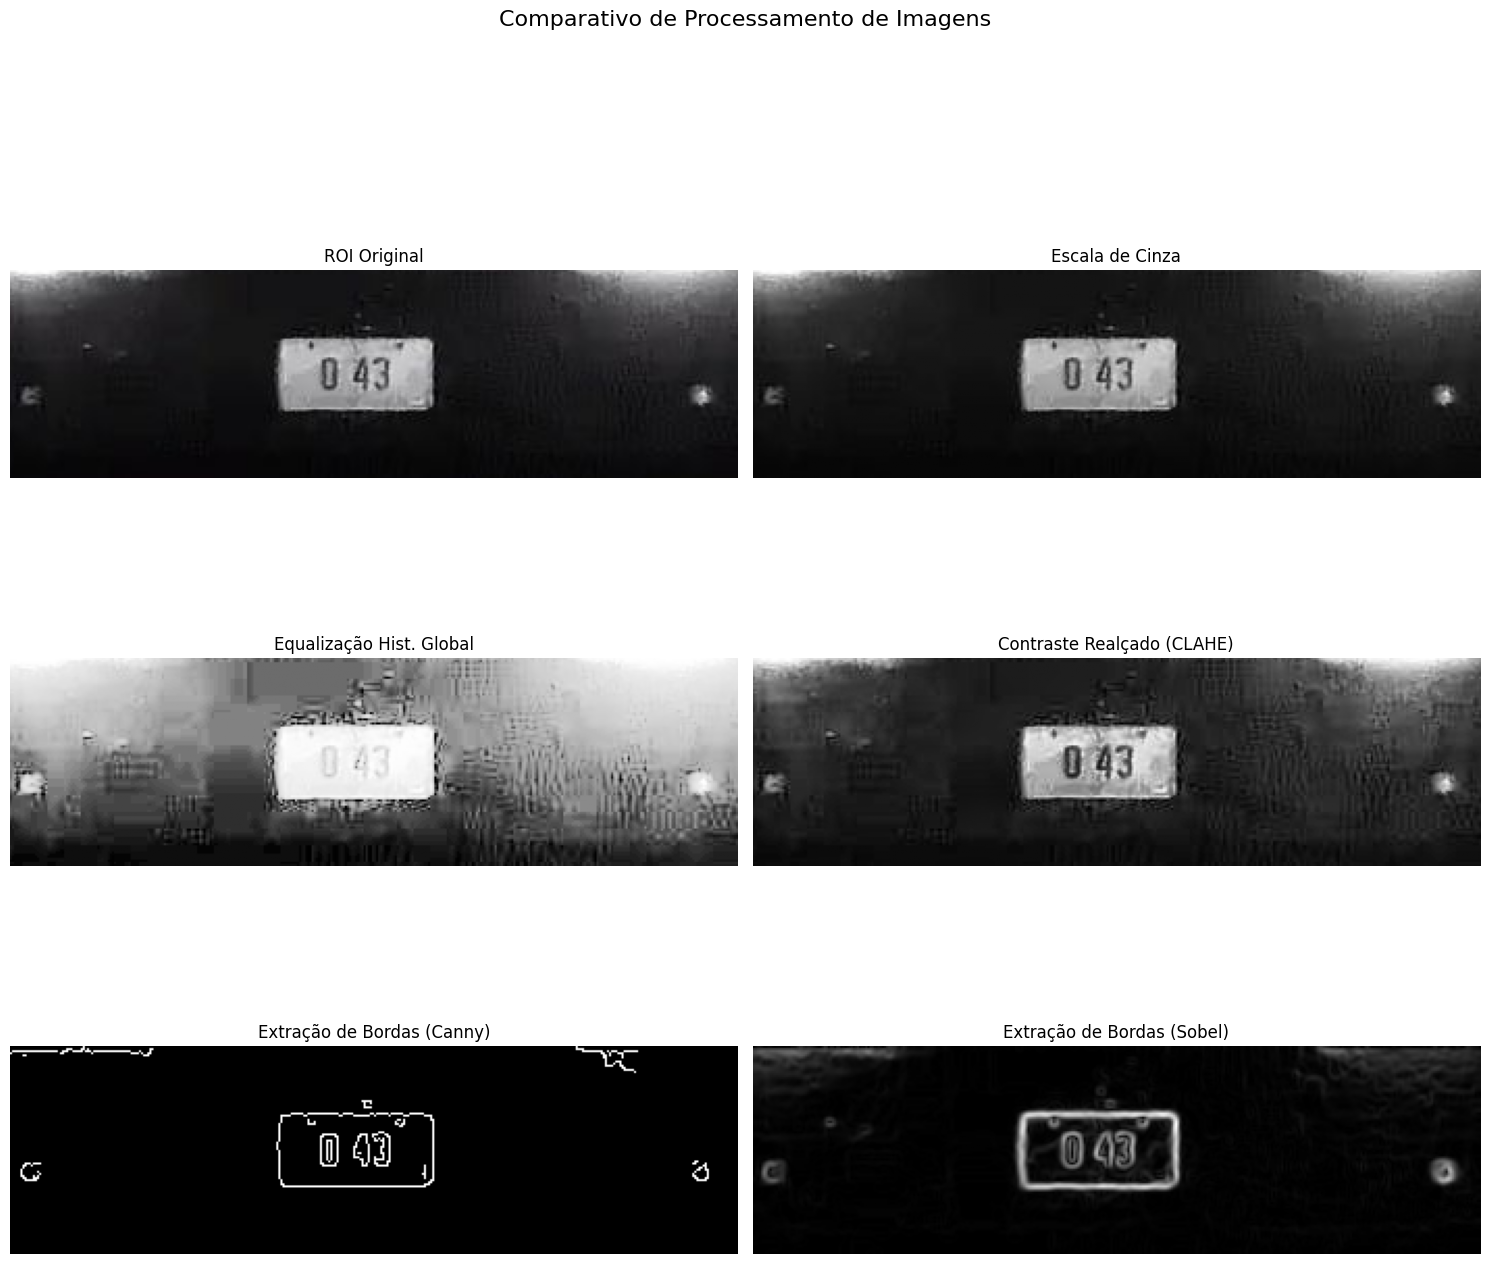

In [24]:
import cv2
import matplotlib.pyplot as plt

# Ensure roi is not empty
if 'roi' not in locals() or roi.size == 0:
    print("")
else:
    # 1. Grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # 2. Noise Reduction (Gaussian Blur)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. Global Histogram Equalization
    equalized = cv2.equalizeHist(gray)

    # 4. Contrast Enhancement (CLAHE - Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(gray)

    # 5. Edge Extraction (Canny)
    canny_edges = cv2.Canny(blurred, 50, 150)

    # 6. Edge Extraction (Sobel)
    sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3) # Sobel X
    sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3) # Sobel Y
    # Combine X and Y gradients to get the magnitude
    sobel_edges = cv2.magnitude(sobelx, sobely)
    # Normalize to 0-255 for display
    sobel_edges = cv2.normalize(sobel_edges, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

    # Display images side-by-side
    fig, axes = plt.subplots(3, 2, figsize=(15, 15)) # Changed to 3 rows, 2 columns
    fig.suptitle('Comparativo de Processamento de Imagens', fontsize=16)

    axes[0, 0].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('ROI Original')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(gray, cmap='gray')
    axes[0, 1].set_title('Escala de Cinza')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(equalized, cmap='gray')
    axes[1, 0].set_title('Equalização Hist. Global')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(contrast_enhanced, cmap='gray')
    axes[1, 1].set_title('Contraste Realçado (CLAHE)')
    axes[1, 1].axis('off')

    axes[2, 0].imshow(canny_edges, cmap='gray')
    axes[2, 0].set_title('Extração de Bordas (Canny)')
    axes[2, 0].axis('off')

    axes[2, 1].imshow(sobel_edges, cmap='gray')
    axes[2, 1].set_title('Extração de Bordas (Sobel)')
    axes[2, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Justificativa Final do Pipeline Escolhido

Considerando que a imagem é noturna, possui ruído, faróis intensos e baixo contraste, o pipeline mais adequado é:

Imagem Original

↓

Escala de Cinza

↓

Gaussian Blur

↓

CLAHE

↓

Canny

Motivos Técnicos: Etapa	Motivo

Escala de Cinza	-> simplificação computacional

Gaussian Blur	-> remoção de ruído

CLAHE ->	melhora contraste local

Canny	-> bordas precisas

As ferramentas escolhidas são justificadas tecnicamente porque aumentam a qualidade visual da imagem, reduzem ruído e tornam mais precisa a detecção de contornos da placa veicular, mesmo em condições subótimas de iluminação noturna, algo essencial em aplicações de Smart Cities, monitoramento urbano e segurança pública.